In [35]:
import numpy as np
import csv,json
import pandas as pd
# Reading DJIA index prices csv file
with open("C:/Users/85290/OneDrive - The Chinese University of Hong Kong/stat3011/DJIA_data.csv", 'rt') as csvfile:  #@@@@@@@with open('./data/DJIA_data.csv', 'rb') as csvfile:
    spamreader = csv.reader(csvfile, delimiter=',')
    # Converting the csv file reader to a lists
    data_list = list(spamreader)

# Separating header from the data
header = data_list[0]
data_list = data_list[1:]
data_list = np.asarray(data_list)
selected_data = data_list[:, [0, 1, 2, 3, 4, 5, 6]]
df = pd.DataFrame(data= selected_data[0:,1:], index=selected_data[0:,0], columns=['open','high','low','close','adjclose','volume'],dtype='float64')
# copy the data to the new dataframe df1 which is temporary dataframe
df1 = df

#idx contains all the data value between given date range
idx = pd.date_range('12-29-2006', '01-01-2017')

# Adding missing dates to the dataframe
df1.index = pd.DatetimeIndex(df1.index)
df1 = df1.reindex(idx, fill_value=np.NaN)
# Reference for pandas interpolation http://pandas.pydata.org/pandas-docs/stable/missing_data.html

interpolated_df = df1.interpolate()
#print interpolated_df.count() # gives 3656 count

# Removing extra date rows added in data for calculating interpolation
df = interpolated_df
print(len(df))
import yfinance as yf

# Define the ticker symbol for DJIA
ticker = "^DJI"

# Fetch DJIA data
djia_data = yf.download(ticker, start="2006-01-03", end="2006-12-29")

data = djia_data.values.tolist()

index= djia_data.index[:250].date.tolist()
df0 = pd.DataFrame(data= data, index=index, columns=['open','high','low','close','adjclose','volume'],dtype='float64')
idx = pd.date_range('01-03-2006', '12-28-2006')
df0.index = pd.DatetimeIndex(df0.index)
df0 = df0.reindex(idx, fill_value=np.NaN)
interpolated_df = df0.interpolate()
df0 = interpolated_df
frames = [df0, df]
df = pd.concat(frames)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pandas_ta as ta
df['EMA_10']=ta.ema(df.adjclose, length=10)
df['EMA_20']=ta.ema(df.adjclose, length=20)
df['EMA_100']=ta.ema(df.adjclose, length=100)
df['EMA_150']=ta.ema(df.adjclose, length=150)
df['HMA_10']=ta.hma(df.adjclose, length=10)
df['HMA_20']=ta.hma(df.adjclose, length=20)
df['HMA_100']=ta.hma(df.adjclose, length=100)
df['HMA_150']=ta.hma(df.adjclose, length=150)
df1=ta.ha(df.open,df.high,df.low,df.adjclose)
df2=ta.donchian(df.high,df.low,20,20)
df3=ta.hilo(df.high,df.low,df.close,13,21)
df4=ta.accbands(df.high,df.low,df.close,length=20)
df5=ta.bbands(df.adjclose,length=5)
df6=ta.aberration(df.high,df.low,df.close,5,15)
df= pd.concat([df,df1,df2,df3,df4], axis=1)
df['LDECAY']=ta.decay(df.adjclose)
df['LR']=ta.log_return(df.adjclose,length=14)
df['ALMA']=ta.alma(df.adjclose,10,6.0,0.85)
df['RSI']=ta.rsi(df.adjclose, length=15)
interpolated_df = df.interpolate()
df= interpolated_df[333:]
df['Target'] = df['adjclose']-df['open']
df['Target'] = df['Target'].shift(-1)
df['TargetClass'] = [1 if df.Target[i]>0 else 0 for i in range(len(df))]
df['TargetNextClose'] = df['adjclose'].shift(-1)
df = df.drop(df.index[-1])
#df = df.drop(['TargetClass','Target','close','HILO_13_21','HILOl_13_21','LDECAY','LR','ALMA','HILO_13_21','HILOl_13_21','ACCBM_20','EMA_10','EMA_20','HMA_100','HMA_150'	],axis=1)
df = df.drop(['TargetClass','close','HILO_13_21','HILOl_13_21','LDECAY','LR','ALMA','HILO_13_21','HILOl_13_21','ACCBM_20','EMA_10','EMA_20','HMA_100','HMA_150'],axis=1)
#df =df[['HA_close','adjclose','ACCBU_20','low','HA_high','DCL_20_20','HMA_20','high','HA_low','HILOs_13_21','HMA_10','DCU_20_20','EMA_150','ACCBL_20','DCM_20_20','EMA_100','TargetNextClose']]
df

[*********************100%%**********************]  1 of 1 completed

3657



C:\Users\85290\AppData\Local\Temp\ipykernel_18284\2018346358.py:64: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df1=ta.ha(df.open,df.high,df.low,df.adjclose)
c:\Users\85290\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas_ta\candles\ha.py:25: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] 

,open,high,low,adjclose,volume,EMA_100,EMA_150,HMA_10,HMA_20,HA_open,HA_high,HA_low,HA_close,DCL_20_20,DCM_20_20,DCU_20_20,HILOs_13_21,ACCBL_20,ACCBU_20,RSI,Target,TargetNextClose
2006-12-02,12212.503255,12268.683268,12125.177083,12224.036458,2.738167e+08,11900.373298,11744.555564,12202.364197,12167.683634,12194.234283,12268.683268,12125.177083,12207.600016,12072.599609,12216.799805,12361.000000,12317.028208,12015.334612,12477.663062,54.234200,49.906250,12253.943034
2006-12-03,12204.036784,12289.326497,12160.373698,12253.943034,2.722233e+08,11907.374679,11751.302418,12229.004719,12171.920580,12200.917150,12289.326497,12160.373698,12226.920003,12072.599609,12216.799805,12361.000000,12317.028208,12014.248293,12488.842287,57.218085,88.279297,12283.849609
2006-12-04,12195.570312,12309.969727,12195.570312,12283.849609,2.706300e+08,11914.829628,11758.356023,12255.868119,12186.254529,12213.918576,12309.969727,12195.570312,12246.239990,12072.599609,12216.799805,12361.000000,12317.028208,12022.611636,12490.045474,60.011523,47.909180,12331.599609
2006-12-05,12283.690430,12335.370117,12276.080078,12331.599609,2.331700e+08,11923.082499,11765.948653,12289.674469,12212.662802,12230.079283,12335.370117,12230.079283,12306.685059,12072.599609,12216.799805,12361.000000,12283.420738,12028.779831,12489.543502,64.029399,-19.469727,12309.250000
2006-12-06,12328.719727,12335.450195,12294.830078,12309.250000,2.208400e+08,11930.729380,11773.144697,12316.555359,12242.513171,12268.382171,12335.450195,12268.382171,12317.062500,12072.599609,12216.799805,12361.000000,12249.813268,12034.526150,12486.479764,60.957893,-31.719727,12278.410156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-27,19943.460938,19980.240234,19939.800781,19945.039063,1.585400e+08,19000.901141,18763.154050,19944.505814,19970.059174,19936.907450,19980.240234,19936.907450,19952.135254,19527.830078,19757.730468,19987.630859,19717.038807,19641.682747,20079.449105,77.960470,-130.630859,19833.679688
2016-12-28,19964.310547,19981.109375,19827.310547,19833.679688,1.883500e+08,19017.391805,18777.333198,19918.674091,19956.862778,19944.521352,19981.109375,19827.310547,19901.602539,19623.189453,19805.410156,19987.630859,19717.038807,19655.002383,20096.933291,63.792732,-15.681641,19819.779297
2016-12-29,19835.460938,19878.439453,19788.939453,19819.779297,1.720400e+08,19033.280666,18791.140431,19877.715249,19933.942990,19923.061946,19923.061946,19788.939453,19830.654785,19664.706380,19826.168620,19987.630859,19717.038807,19667.769183,20098.437396,62.279061,-15.681641,19819.779297
2016-12-30,19835.460938,19878.439453,19788.939453,19819.779297,1.720400e+08,19048.854897,18804.764787,19836.642789,19905.452096,19876.858365,19878.439453,19788.939453,19830.654785,19706.223307,19846.927083,19987.630859,19943.795523,19676.549023,20100.762972,62.279061,-15.681641,19819.779297


In [36]:
df.reset_index(inplace = True)
data_set = df.iloc[:, 1:23]#.values
pd.set_option('display.max_columns', None)

data_set.head()

,open,high,low,adjclose,volume,EMA_100,EMA_150,HMA_10,HMA_20,HA_open,HA_high,HA_low,HA_close,DCL_20_20,DCM_20_20,DCU_20_20,HILOs_13_21,ACCBL_20,ACCBU_20,RSI,Target,TargetNextClose
0,12212.503255,12268.683268,12125.177083,12224.036458,2.738167e+08,11900.373298,11744.555564,12202.364197,12167.683634,12194.234283,12268.683268,12125.177083,12207.600016,12072.599609,12216.799805,12361.0,12317.028208,12015.334612,12477.663062,54.234200,49.906250,12253.943034
1,12204.036784,12289.326497,12160.373698,12253.943034,2.722233e+08,11907.374679,11751.302418,12229.004719,12171.920580,12200.917150,12289.326497,12160.373698,12226.920003,12072.599609,12216.799805,12361.0,12317.028208,12014.248293,12488.842287,57.218085,88.279297,12283.849609
2,12195.570312,12309.969727,12195.570312,12283.849609,2.706300e+08,11914.829628,11758.356023,12255.868119,12186.254529,12213.918576,12309.969727,12195.570312,12246.239990,12072.599609,12216.799805,12361.0,12317.028208,12022.611636,12490.045474,60.011523,47.909180,12331.599609
3,12283.690430,12335.370117,12276.080078,12331.599609,2.331700e+08,11923.082499,11765.948653,12289.674469,12212.662802,12230.079283,12335.370117,12230.079283,12306.685059,12072.599609,12216.799805,12361.0,12283.420738,12028.779831,12489.543502,64.029399,-19.469727,12309.250000
4,12328.719727,12335.450195,12294.830078,12309.250000,2.208400e+08,11930.729380,11773.144697,12316.555359,12242.513171,12268.382171,12335.450195,12268.382171,12317.062500,12072.599609,12216.799805,12361.0,12249.813268,12034.526150,12486.479764,60.957893,-31.719727,12278.410156


In [37]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range=(-1,1))
data_set_scaled = sc.fit_transform(data_set)
print(data_set_scaled)
print(data_set_scaled.shape)

[[-0.15578752 -0.16266537 -0.16044798 ...  0.06439658 -0.0301337
  -0.14997375]
 [-0.1570491  -0.15955599 -0.15522284 ...  0.13969916  0.01502806
  -0.14551924]
 [-0.15831069 -0.1564466  -0.14999769 ...  0.21019555 -0.03248407
  -0.13840701]
 ...
 [ 0.98010577  0.98355306  0.97728305 ...  0.26742009 -0.10732496
   0.97693703]
 [ 0.98010577  0.98355306  0.97728305 ...  0.26742009 -0.10732496
   0.97693703]
 [ 0.98010577  0.98355306  0.97728305 ...  0.26742009 -0.10732496
   0.97693703]]
(3683, 22)


In [38]:
# multiple feature from data provided to the model
X = []
#print(data_set_scaled[0].size)
#data_set_scaled=data_set.values
backcandles = 30
print(data_set_scaled.shape[0])
for j in range(21):#data_set_scaled[0].size):#2 columns are target not X
    X.append([])
    for i in range(backcandles, data_set_scaled.shape[0]):#backcandles+2
        X[j].append(data_set_scaled[i-backcandles:i, j])

#move axis from 0 to position 2
X=np.moveaxis(X, [0], [2])

#Erase first elements of y because of backcandles to match X length
#del(yi[0:backcandles])
#X, yi = np.array(X), np.array(yi)
# Choose -1 for last column, classification else -2...
X, yi =np.array(X), np.array(data_set_scaled[backcandles:,-1])
y=np.reshape(yi,(len(yi),1))
#y=sc.fit_transform(yi)
#X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
#print(X)
print(X.shape)
#print(y)
print(y.shape)

3683
(3653, 30, 21)
(3653, 1)


In [39]:
splitlimit = int(len(X)*0.8)
print(splitlimit)
X_train, X_test = X[:splitlimit], X[splitlimit:]
y_train, y_test = y[:splitlimit], y[splitlimit:]
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
print(y_train)

2922
(2922, 30, 21)
(731, 30, 21)
(2922, 1)
(731, 1)
[[-0.11745816]
 [-0.11711948]
 [-0.11620034]
 ...
 [ 0.70336421]
 [ 0.67953264]
 [ 0.68027142]]


In [40]:
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dropout
from keras.layers import Dense
from keras.layers import TimeDistributed

import tensorflow as tf
import keras
from keras import optimizers
from keras.callbacks import History
from keras.models import Model
from keras.layers import Dense, Dropout, LSTM, Input, Activation, concatenate
import numpy as np
tf.random.set_seed(20)
np.random.seed(10)

lstm_input = Input(shape=(backcandles, 21), name='lstm_input')
inputs = LSTM(150, name='first_layer')(lstm_input)
inputs = Dense(1, name='dense_layer')(inputs)
output = Activation('linear', name='output')(inputs)
model = Model(inputs=lstm_input, outputs=output)
adam = optimizers.Adam()
model.compile(optimizer=adam, loss='mse')
model.fit(x=X_train, y=y_train, batch_size=15, epochs=30, shuffle=True, validation_split = 0.1)

Epoch 1/30


176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0108 - val_loss: 5.6956e-04
Epoch 2/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 4.9017e-04 - val_loss: 0.0011
Epoch 3/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.5780e-04 - val_loss: 9.7834e-04
Epoch 4/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 4.3724e-04 - val_loss: 0.0011
Epoch 5/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 4.3250e-04 - val_loss: 0.0012
Epoch 6/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 4.2841e-04 - val_loss: 0.0012
Epoch 7/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 4.2223e-04 - val_loss: 0.0011
Epoch 8/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 4.1495e-04 - val_loss: 0.0011
Epoch 9/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 4.0774e-04 - val_loss: 0.0010
Epoch 10/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 4.0117e-04 - val_loss: 9.7751e-04
Epoch 11/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 3.9539e-04 - val_loss: 9.2975e

In [41]:
def denormalize_value(normalized_value, min_value, max_value):
    denormalized_value = (normalized_value + 1) * 0.5 * (max_value - min_value) + min_value
    return denormalized_value

y_pred = model.predict(X_test)
dt =data_set.iloc[:, -1]
dt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
r2 = r2_score(y_test,y_pred)
print("R-squared:", r2)
mse = mean_squared_error(dt.iloc[-731:],denormalize_value(y_pred,data_set.TargetNextClose.min(),data_set.TargetNextClose.max()))
print("mean_squared_error:", mse)
mae = mean_absolute_error(dt.iloc[-731:],denormalize_value(y_pred,data_set.TargetNextClose.min(),data_set.TargetNextClose.max()))
print("mean_absolute_error:", mae)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
R-squared: 0.9648122867305501
mean_squared_error: 22432.352103732486
mean_absolute_error: 117.902326635773


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


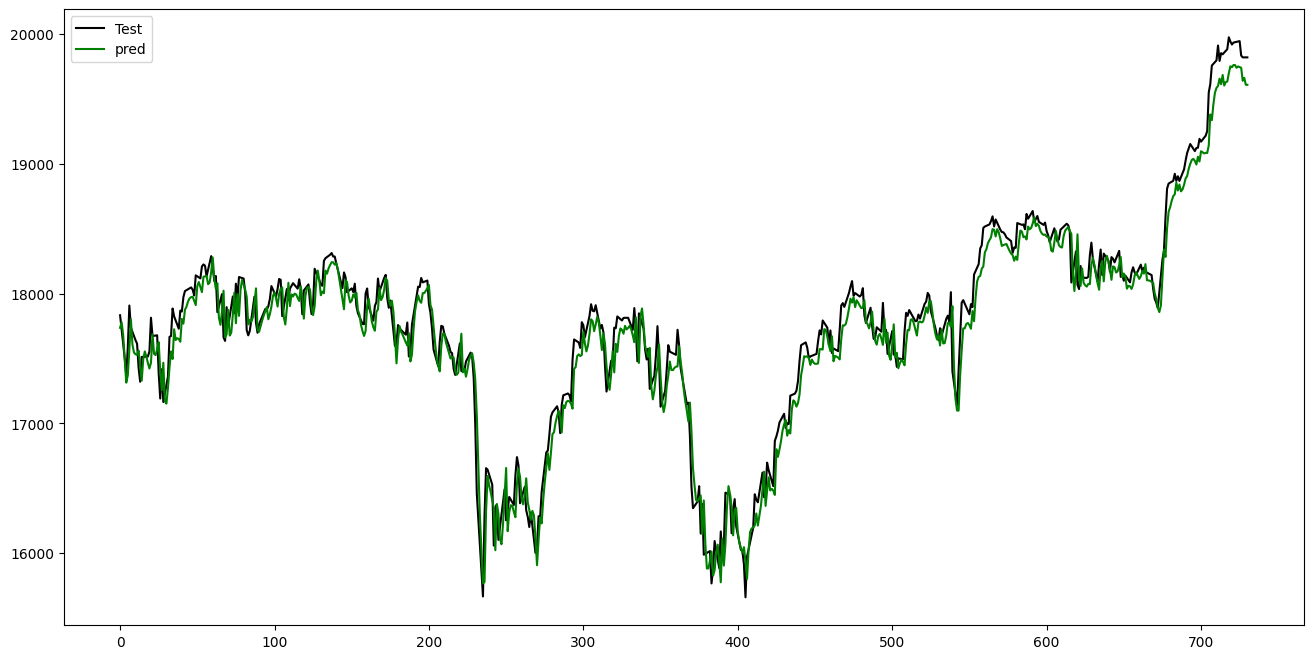

In [42]:
y_pred = model.predict(X_test)
plt.figure(figsize=(16,8))
plt.plot(dt.iloc[-731:].reindex().reset_index(drop=True), color = 'black', label = 'Test')
plt.plot(denormalize_value(y_pred,data_set.TargetNextClose.min(),data_set.TargetNextClose.max()), color = 'green', label = 'pred')
plt.legend()
plt.show()